In [1]:
from config import *
from utils import *

In [2]:
import os
import pandas as pd

In [3]:
# model name to be included in file names later
title = 'my_m9-vh_retention'#update with each run

In [4]:
#create df of all variable to be plotted

# Function to run the model 100 times and collect the results
def run_model_100_times():
    results = []
    for _ in range(100):
        
        coral_model_results = run_coral_model(PSD_T0, MaxYear)
        benthic_cover_results = opts.yearly_benthic_cover_df
        rugosity_results = get_rugosity_list()
        
        # Merge the results into a single DataFrame
        merged_results = pd.merge(coral_model_results, benthic_cover_results, on='Year')
        merged_results['Rugosity'] = rugosity_results
        
        results.append(merged_results)
    
    # Concatenate all the results into a single DataFrame
    final_df = pd.concat(results)
    
    return final_df

# Run the model 100 times and get the final DataFrame
final_df = run_model_100_times()

# Print the final DataFrame
print(final_df)



    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.000000          2.900000       38.100000   
1      1            2.060002          2.950639       39.170259   
2      2            2.055207          3.035927       40.150408   
3      3            2.077009          3.156637       41.493250   
4      4            2.090309          3.343867       42.558403   
..   ...                 ...               ...             ...   
9      9            1.556954          4.322763       34.144429   
10    10            1.610547          5.256444       36.059053   
11    11            1.606237          6.235973       37.333862   
12    12            1.567076          7.357855       38.793898   
13    13            1.484383          8.486640       40.455948   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               43.000000                57.000000                48.000000   
1               44.180900                55.81910

In [ ]:
# Export df to an Excel file
excel_dir = r'C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\happyreef_testing\data'
os.makedirs(excel_dir, exist_ok=True)
excel_path = os.path.join(excel_dir, f'{title}.xlsx')
final_df.to_excel(excel_path, index=False)

print(f"Final DataFrame has been exported to {excel_path}")


In [ ]:
#plot MG-{title} with SD

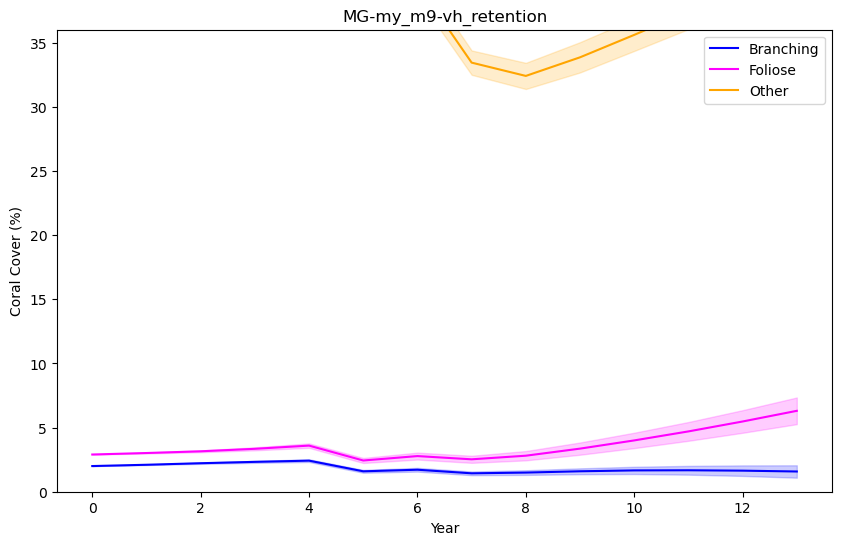

Graph has been saved to C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\happyreef_testing\plots/MG-my_m9-vh_retention.png


In [5]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
years = average_branching.index

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = r'C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\happyreef_testing\plots'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

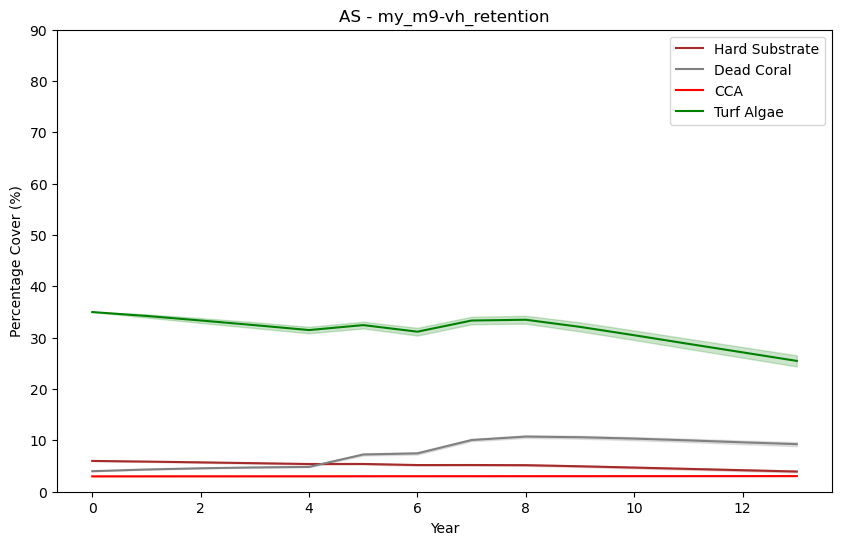

AS graph has been saved to C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\happyreef_testing\plots/AS-my_m9-vh_retention.png


In [6]:

#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years = average_hard_substrate.index

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

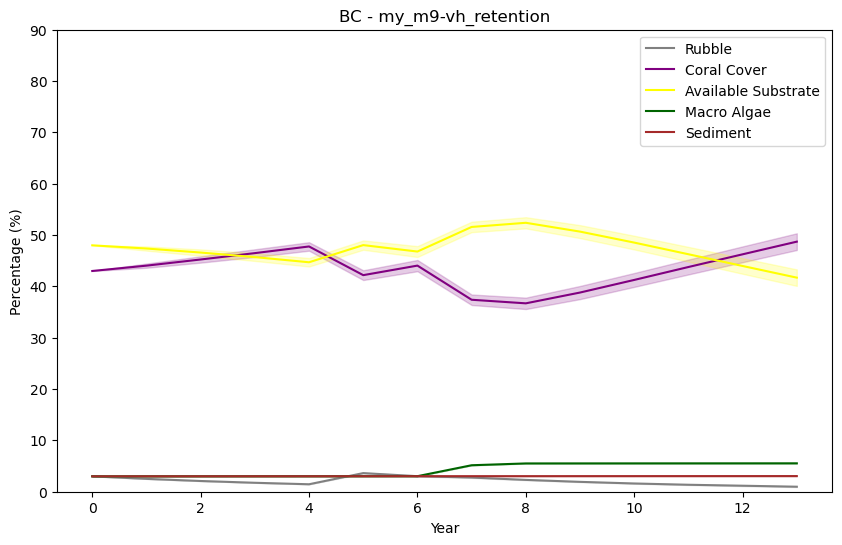

BC graph has been saved to C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\happyreef_testing\plots/BC-my_m9-vh_retention.png


In [7]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years = average_rubble.index

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

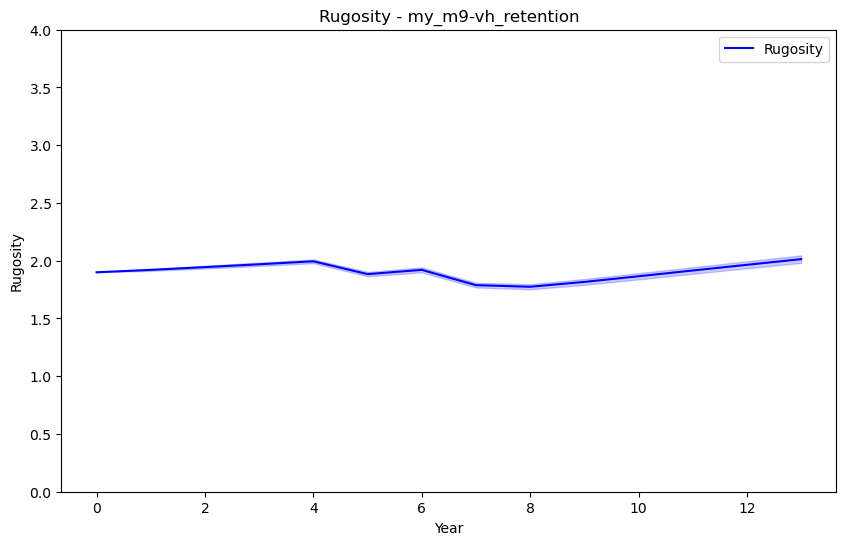

Rugosity graph has been saved to C:\Users\uqrbutto\OneDrive - The University of Queensland\PhD_proj_pollution_on_coral_reefs\Coral_model_Rios_branch_1\happyreef_testing\plots/Rugosity-my_m9-vh_retention.png


In [8]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years = average_rugosity.index

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")
